# Improved Blog Writing

In [2]:
from __future__ import annotations

import operator
from typing import TypedDict,List,Annotated,Literal
from pathlib import Path
from dotenv import load_dotenv

from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END
from langgraph.types import Send

from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from langchain_core.messages import SystemMessage,HumanMessage
from langchain_core.prompt_values import ChatPromptValue
from langchain_core.output_parsers import PydanticOutputParser
from langchain_classic.output_parsers import OutputFixingParser,RetryWithErrorOutputParser


c:\Coding\Python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()

True

In [4]:
class Task(BaseModel):
    id:int
    title:str
    goal:str=Field(
        description="One sentence describing what the reader should be able to do/understand after this section."
    )
    bullets:List[str]=Field(
        min_length=2,
        max_length=5,
        description="2-5 concrete, non-overlapping subpoints to cover in this section."
    )
    target_words:int=Field(
        description="Target word count for this section (120-450)."
    )
    section_type:Literal[
        "intro","core","examples","checklist","common_mistakes","conclusion"
    ]=Field(
        description="Use 'common_mistakes' exactly once in the plan."
    )
    # brief:str=Field(
    #     description="what to cover"
    # )

In [5]:
class Plan(BaseModel):
    blog_title:str
    audience:str=Field(description="Who this blog is for.")
    tone:str=Field(description="Writing tone (e.g., practical, crisp).")
    tasks:list[Task]

In [6]:
class State(TypedDict):
    topic:str
    plan:Plan
    sections:Annotated[List[str],operator.add]
    result:str


In [7]:
# Yeh setup top par rakho
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Meta-Llama-3-8B-Instruct",  # Model change karna zaruri hai
    task="text-generation",
    max_new_tokens=2500,
    temperature=0.1
)

model = ChatHuggingFace(llm=llm)
parser = PydanticOutputParser(pydantic_object=Plan)
retry_parser = RetryWithErrorOutputParser.from_llm(parser=parser, llm=model)

In [8]:
# 1. Add this import at the top
from langchain_core.prompt_values import ChatPromptValue

# 3. Replace your ENTIRE orchestrator function with this
def orchestrator(state: State) -> dict:
    format_instructions = parser.get_format_instructions()
    
    prompt_value = ChatPromptValue(messages=[
        SystemMessage(
            content=f"""You are a senior technical writer and developer advocate. Produce a highly actionable outline for a technical blog post.
            CRITICAL SCHEMA RULES:
            1. EVERY task MUST have exactly 2 to 5 items in the `bullets` list.
            2. EVERY task MUST include ALL 6 fields: `id`, `title`, `goal`, `bullets`, `target_words`, and `section_type`.
            
            YOU MUST RETURN YOUR ANSWER AS A VALID JSON OBJECT EXACTLY MATCHING THIS TEMPLATE:
            {{
              "blog_title": "Example Title",
              "audience": "Intermediate developers",
              "tone": "Practical",
              "tasks": [
              {{
                "id": 1,
                "title": "Introduction",
                "goal": "Understand the core problem.",
                "bullets": [
                "Point 1",
                "Point 2"
                ],
                "target_words": 200,
                "section_type": "intro"
                }},
                {{
                  "id": 2,
                  "title": "Core Concepts",
                  "goal": "Learn the architecture.",
                  "bullets": [
                  "Point A",
                  "Point B"
                  ],
                  "target_words": 300,
                  "section_type": "core"
                  }}
                  ]
              }}
              CRITICAL INSTRUCTIONS FOR OUTPUT:
              - Return ONLY valid JSON.
              - DO NOT wrap the JSON in markdown code blocks.
              - DO NOT add conversational text.
              {format_instructions}"""
              ),
              HumanMessage(
                  content=f"Topic: {state['topic']}\nGenerate the JSON plan now."
                  )
                  ])
    raw_response = model.invoke(prompt_value)
    
    try:
        plan = parser.parse(raw_response.content)
    except Exception:
        plan = retry_parser.parse_with_prompt(raw_response.content, prompt_value)
        
    return {
        "plan": plan
    }

In [9]:
# def orchestrator(state: State) -> dict:
#     format_instructions = parser.get_format_instructions()
    
#     # NOTICE ChatPromptValue HERE! This is what prevents the 'to_string' error.
#     prompt_value = ChatPromptValue(messages=[
#         SystemMessage(
#             content=f"""You are a senior technical writer and developer advocate. Your job is to produce a highly actionable outline for a technical blog post.

# Hard requirements:
# - Create 5-7 sections (tasks).
# - Make it technical and actionable.

# CRITICAL SCHEMA RULES:
# 1. EVERY task MUST have exactly 2 to 5 items in the `bullets` list. No exceptions.
# 2. EVERY task MUST include ALL 6 fields: `id`, `title`, `goal`, `bullets`, `target_words`, and `section_type`. Do not drop ANY fields!

# YOU MUST RETURN YOUR ANSWER AS A VALID JSON OBJECT EXACTLY MATCHING THIS TEMPLATE:
# {{
#   "blog_title": "Example Title",
#   "audience": "Intermediate developers",
#   "tone": "Practical",
#   "tasks": [
#     {{
#       "id": 1,
#       "title": "Introduction",
#       "goal": "Understand the core problem.",
#       "bullets": [
#         "Point 1",
#         "Point 2"
#       ],
#       "target_words": 200,
#       "section_type": "intro"
#     }},
#     {{
#       "id": 2,
#       "title": "Core Concepts",
#       "goal": "Learn the architecture.",
#       "bullets": [
#         "Point A",
#         "Point B"
#       ],
#       "target_words": 300,
#       "section_type": "core"
#     }}
#   ]
# }}

# CRITICAL INSTRUCTIONS FOR OUTPUT:
# - Return ONLY valid JSON.
# - DO NOT wrap the JSON in markdown code blocks (e.g., do not use ```json).
# - DO NOT add any conversational text before or after the JSON.

# {format_instructions}"""
#         ),
#         HumanMessage(
#             content=f"Topic: {state['topic']}\nGenerate the JSON plan now."
#         )
#     ])

#     # Get the raw response from the model
#     raw_response = model.invoke(prompt_value)
    
#     try:
#         # Try to parse it normally
#         plan = parser.parse(raw_response.content)
#     except Exception as e:
#         # If Pydantic fails, the retry parser will catch it without crashing!
#         print(f"Validation failed, retrying... Error: {e}")
#         plan = retry_parser.parse_with_prompt(raw_response.content, prompt_value)
        
#     return {
#         "plan": plan
#     }

In [10]:
# def orchestrator(state: State) -> dict:
#     format_instructions = parser.get_format_instructions()
    
#     # 1. Define the prompt (DO NOT use .invoke here)
#     prompt_value = [
#         SystemMessage(
#             content=f"""You are a senior technical writer and developer advocate. Your job is to produce a highly actionable outline for a technical blog post.

# Hard requirements:
# - Create 5-7 sections (tasks) that fit a technical blog.
# - Each section must include:
#   1) goal (1 sentence: what the reader can do/understand after the section)
#   2) 3-5 bullets that are concrete, specific, and non-overlapping
#   3) target word count (120-450)
# - Include EXACTLY ONE section with section_type='common_mistakes'.

# Make it technical (not generic):
# - Assume the reader is a developer; use correct terminology.
# - Prefer design/engineering structure: problem → intuition → approach → implementation → trade-offs → testing/observability → conclusion.
# - Bullets must be actionable and testable.
# - Explicitly include at least ONE of the following somewhere in the plan (as bullets):
#   * a minimal working example (MWE) or code sketch
#   * edge cases / failure modes
#   * performance/cost considerations
#   * security/privacy considerations (if relevant)
#   * debugging tips / observability (logs, metrics, traces)

# Ordering guidance:
# - Start with a crisp intro and problem framing.
# - Build core concepts before advanced details.
# - Include one section for common mistakes and how to avoid them.
# - End with a practical summary/checklist and next steps.

# CRITICAL SCHEMA RULES:
# 1. EVERY task MUST have exactly 2 to 5 items in the `bullets` list. No exceptions.
# 2. EVERY task MUST include ALL fields, including `target_words` and `section_type`. Do not drop fields!

# EXAMPLE EXPECTED OUTPUT FORMAT:
# {{
#   "blog_title": "Example Title",
#   "audience": "Intermediate developers",
#   "tone": "Practical",
#   "tasks": [
#     {{
#       "id": 1,
#       "title": "Introduction",
#       "goal": "Understand the core problem.",
#       "bullets": ["Point 1", "Point 2"],
#       "target_words": 200,
#       "section_type": "intro"
#     }},
#     {{
#       "id": 2,
#       "title": "Next Section",
#       "goal": "Learn how to build X.",
#       "bullets": ["Point A", "Point B"],
#       "target_words": 350,
#       "section_type": "core"
#     }}
#   ]
# }}

# Output must strictly match the Plan schema.

# CRITICAL INSTRUCTIONS FOR OUTPUT:
# - Return ONLY valid JSON.
# - DO NOT wrap the JSON in markdown code blocks (e.g., do not use ```json).
# - DO NOT include any conversational text before or after the JSON.

# {format_instructions}"""
#         ),
#         HumanMessage(
#             content=f"Topic: {state['topic']}"
#         )
#     ]

#     # 2. Get the raw response from the model
#     raw_response = model.invoke(prompt_value)
    
#     # 3. Try parsing, and use retry_parser if Pydantic validation fails
#     try:
#         plan = parser.parse(raw_response.content)
#     except Exception as e:
#         print(f"Validation failed, retrying... Error: {e}")
#         plan = retry_parser.parse_with_prompt(raw_response.content, prompt_value)
        
#     return {
#         "plan": plan
#     }

In [11]:
# def orchestrator(state: State) -> dict:
#     format_instructions = parser.get_format_instructions()

#     messages = [
#         SystemMessage(
#             content=f"""You are a senior technical writer and developer advocate. Your job is to produce a highly actionable outline for a technical blog post.

# Hard requirements:
# - Create 5-7 sections (tasks) that fit a technical blog.
# - Each section must include:
#   1) goal (1 sentence: what the reader can do/understand after the section)
#   2) 2-5 bullets that are concrete, specific, and non-overlapping
#   3) target word count (120-450)
# - Include EXACTLY ONE section with section_type='common_mistakes'.

# Make it technical (not generic):
# - Assume the reader is a developer; use correct terminology.
# - Prefer design/engineering structure:
#   problem → intuition → approach → implementation → trade-offs → testing/observability → conclusion.

# - Bullets must be actionable and testable.
# - Include at least one of:
#   * minimal working example
#   * edge cases / failure modes
#   * performance considerations
#   * debugging tips

# Output must strictly match the Plan schema.

# CRITICAL:
# - Return ONLY valid JSON.
# - No markdown code fences.
# - No explanation text.

# {format_instructions}
# """
#         ),
#         HumanMessage(
#             content=f"Topic: {state['topic']}"
#         )
#     ]

#     raw_response = model.invoke(messages)

#     print("\n========== RAW OUTPUT ==========")
#     print(raw_response.content)
#     print("================================\n")

#     try:
#         plan = parser.parse(raw_response.content)

#     except Exception as e:
#         print(f"Parser failed: {e}")
#         print("Trying OutputFixingParser...")

#         plan = fixing_parser.parse(raw_response.content)

#     return {
#         "plan": plan
#     }

In [12]:
def no_of_worker(state:State):
    return [
        Send(
            "Worker",
            {"task":task,"topic":state["topic"],"plan":state["plan"]}
        )
        for task in state["plan"].tasks
    ]

In [13]:
def worker(payload:dict)->dict:

    task=payload['task']
    topic=payload['topic']
    plan=payload['plan']

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    section_md=model.invoke([
        SystemMessage(
            content="""You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n\n"
            "Hard constraints:\n"
            "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
            "- Stay close to the Target words (±15%).\n"
            "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
        "Technical quality bar:\n"
        "- Be precise and implementation-oriented (developers should be able to apply it).\n"
        "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
        "- When relevant, include at least one of:\n"
        "  * a small code snippet (minimal, correct, and idiomatic)\n"
        "  * a tiny example input/output\n"
        "  * a checklist of steps\n"
        "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
        "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
        "- Call out edge cases / failure modes and what to do about them.\n"
        "- If you mention a best practice, add the 'why' in one sentence.\n\n"
        "Markdown style:\n"
        "- Start with a '## <Section Title>' heading.\n"
        "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
        "- Avoid fluff. Avoid marketing language.\n"
        "- If you include code, keep it focused on the bullet being addressed.\n"""
        ),
        HumanMessage(
            content=(
                f"Blog: {plan.blog_title}\n"
                f"Audience: {plan.audience}\n"
                f"Tone: {plan.tone}\n"
                f"Topic: {topic}\n\n"
                f"Section: {task.title}\n"
                f"Section type: {task.section_type}\n"
                f"Goal: {task.goal}\n"
                f"Target words: {task.target_words}\n"
                f"Bullets:{bullets_text}\n"
                "Return only the section content in Markdown."
            )
        )
    ]).content.strip()

    return{
        'sections':[section_md]
    }



In [14]:
def reducer(state:State)->dict:

    title=state['plan'].blog_title
    body="\n\n".join(state['sections']).strip()

    result=f'#{title}\n\n{body}\n'

    # Save to file
    filename=title.lower().replace(" ","-")+".md"
    output_path=Path(filename)
    output_path.write_text(result,encoding="utf-8")

    return{
        "result":result
    }

In [15]:
graph=StateGraph(State)

graph.add_node("Orchestrator",orchestrator)
graph.add_node("Worker",worker)
graph.add_node("Reducer",reducer)

In [16]:
graph.add_edge(START,"Orchestrator")
graph.add_conditional_edges("Orchestrator",no_of_worker,["Worker"])
graph.add_edge("Worker","Reducer")
graph.add_edge("Reducer",END)

app=graph.compile()

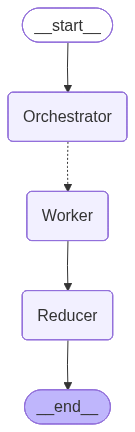

In [17]:
app

In [18]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

OutputParserException: Failed to parse Plan from completion {"blog_title": "Mastering Self-Attention in Deep Learning", "audience": "Advanced developers", "tone": "Technical", "tasks": [{"id": 1, "title": "Introduction", "goal": "Understand the concept of self-attention in deep learning.", "bullets": ["What is self-attention?", "Why is self-attention important in deep learning?", "How does self-attention differ from traditional recurrent neural networks?"], "target_words": 250, "section_type": "intro"}, {"id": 2, "title": "Core Concepts", "goal": "Learn the mathematical formulation of self-attention.", "bullets": ["Attention mechanism", "Query, Key, and Value matrices", "Scaled dot-product attention", "Multi-head attention"], "target_words": 350, "section_type": "core"}, {"id": 3, "title": "Applications", "goal": "Explore the use cases of self-attention in natural language processing and computer vision.", "bullets": ["Language models", "Machine translation", "Image captioning", "Visua

In [ ]:
print(out['plan'])

NameError: name 'out' is not defined